ПРАКТИЧЕСКАЯ РАБОТА 4.1: ГРАДИЕНТНЫЙ СПУСК ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ

1. ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛА ml1var17.npy
   Размер исходных данных: (36, 2)
   Данные для анализа (без точки предсказания): (35, 2)
   Значение x для предсказания: 25.0

2. ОБНАРУЖЕНЫ ВЫБРОСЫ:
   Индексы выбросов: [13]
   Значения x: [2.6]
   Значения y: [15.]

3. ДАННЫЕ ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ:
   Количество точек: 34

4. СТАТИСТИКА ДАННЫХ:
   x: от 0.00 до 6.80, среднее=3.42
   y: от 1.89 до 3.24, среднее=2.60

7. АНАЛИТИЧЕСКОЕ РЕШЕНИЕ (МНК):
   k = 0.157551
   b = 2.063152
   MSE = 0.022688

5. ЗАПУСК ГРАДИЕНТНОГО СПУСКА:
   Скорость обучения: 0.05
   Максимальное число итераций: 500
   Итерация  100: loss = 0.028786, k = 0.1909, b = 1.9109
   Итерация  200: loss = 0.022726, k = 0.1602, b = 2.0512
   Ранняя остановка на итерации 282

6. РЕЗУЛЬТАТЫ ГРАДИЕНТНОГО СПУСКА:
   Финальные значения: k = 0.1579, b = 2.0617
   Финальная ошибка: 0.022689

8. СРАВНЕНИЕ РЕЗУЛЬТАТОВ:
   Метод                k            b          

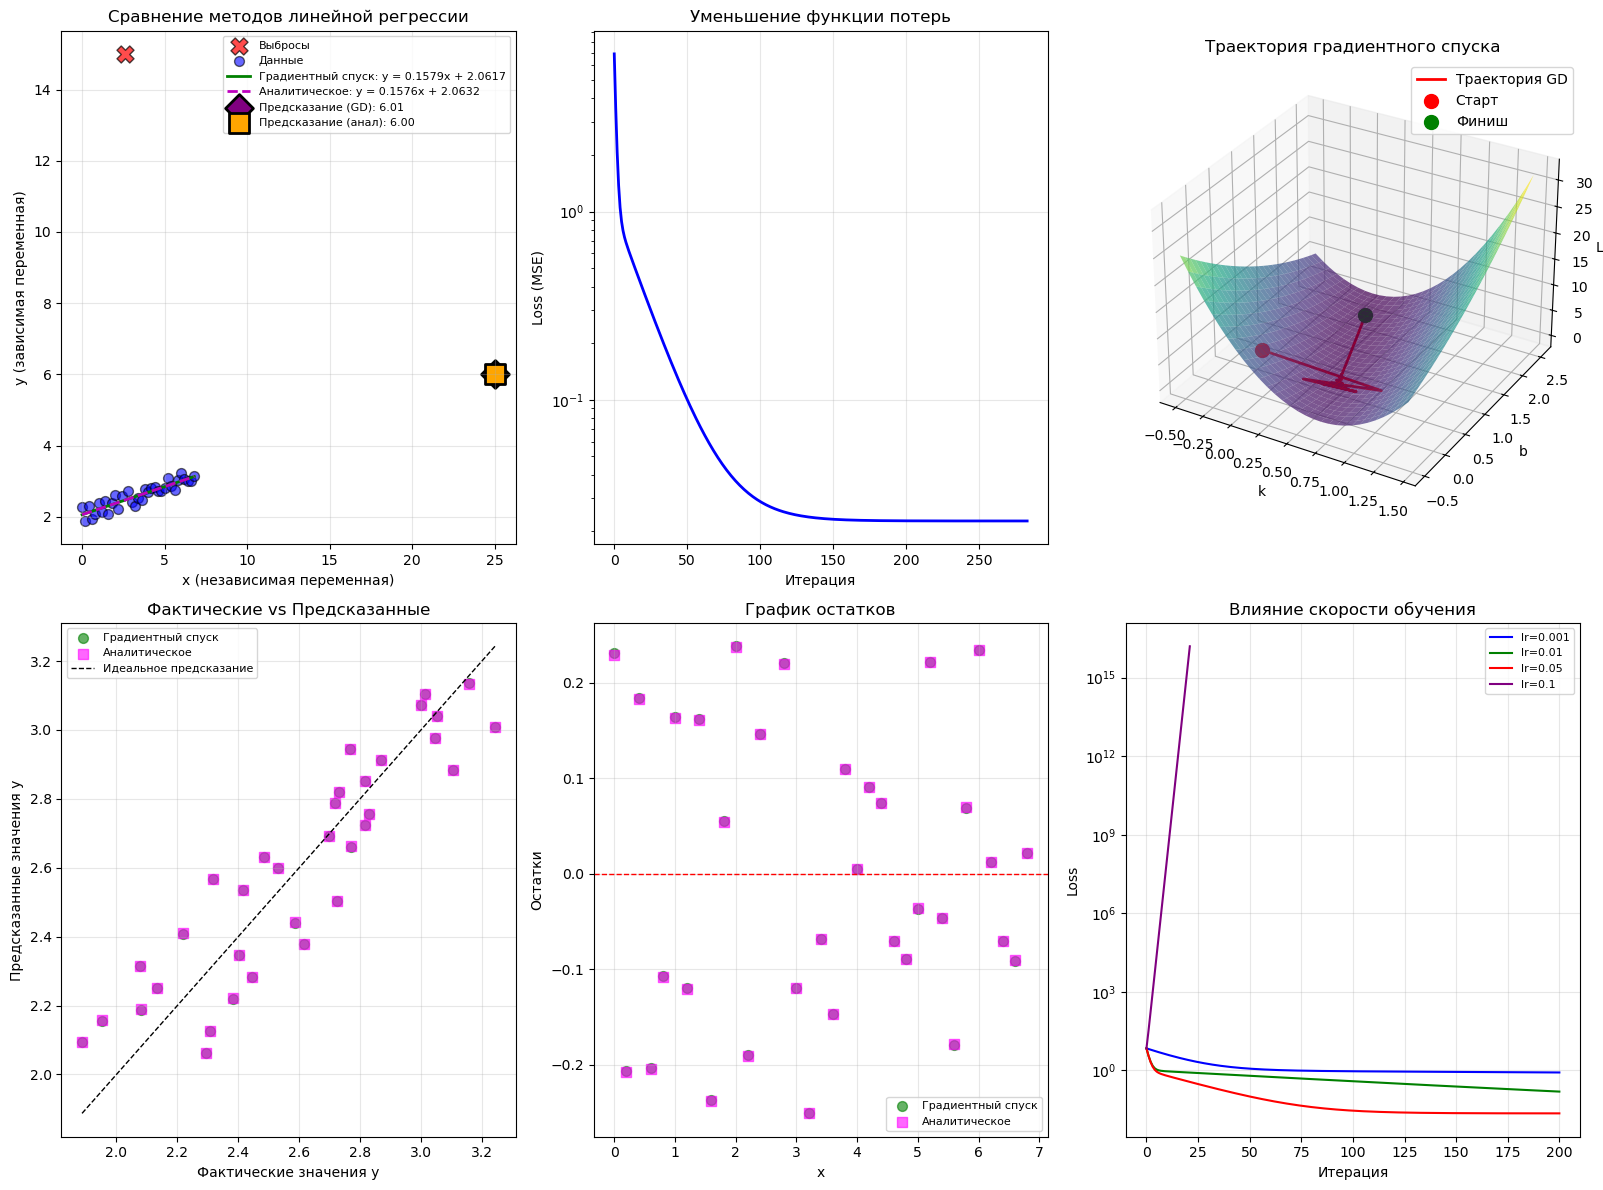


РАБОТА 4.1 ЗАВЕРШЕНА
Результаты сохранены в файле: gradient_descent_linear_results.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import warnings
warnings.filterwarnings('ignore')

print("ПРАКТИЧЕСКАЯ РАБОТА 4.1: ГРАДИЕНТНЫЙ СПУСК ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ")
def load_and_prepare_data(filename='ml1var17.npy'):
    try:
        data = np.load(filename)
        print(f"\n1. ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛА {filename}")
        print(f"   Размер исходных данных: {data.shape}")
        
        # Отделяем данные для предсказания
        x_pred = data[-1, 0]
        data_main = data[:-1]  # Убираем последнюю строку с x для предсказания
        
        print(f"   Данные для анализа (без точки предсказания): {data_main.shape}")
        print(f"   Значение x для предсказания: {x_pred}")
        
        # Обнаружение и удаление выбросов
        X_full = data_main[:, 0]
        y_full = data_main[:, 1]
        
        # Вычисляем Z-оценки для обнаружения выбросов
        y_mean = np.mean(y_full)
        y_std = np.std(y_full)
        z_scores = (y_full - y_mean) / y_std
        
        # Находим выбросы (|z| >= 3)
        outlier_indices = np.where(np.abs(z_scores) >= 3)[0]
        
        if len(outlier_indices) > 0:
            print(f"\n2. ОБНАРУЖЕНЫ ВЫБРОСЫ:")
            print(f"   Индексы выбросов: {outlier_indices}")
            print(f"   Значения x: {X_full[outlier_indices]}")
            print(f"   Значения y: {y_full[outlier_indices]}")
            
            # Удаляем выбросы
            mask = np.ones(len(y_full), dtype=bool)
            mask[outlier_indices] = False
            X = X_full[mask]
            y = y_full[mask]
            
            print(f"\n3. ДАННЫЕ ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ:")
            print(f"   Количество точек: {len(X)}")
        else:
            X = X_full
            y = y_full
            print(f"\n2. ВЫБРОСЫ НЕ ОБНАРУЖЕНЫ")
        
        # Статистика по данным
        print(f"\n4. СТАТИСТИКА ДАННЫХ:")
        print(f"   x: от {X.min():.2f} до {X.max():.2f}, среднее={X.mean():.2f}")
        print(f"   y: от {y.min():.2f} до {y.max():.2f}, среднее={y.mean():.2f}")
        
        return X, y, x_pred, outlier_indices, data_main
    
    except FileNotFoundError:
        print(f"Файл {filename} не найден. Создаю тестовые данные...")
        # Создаем тестовые данные на основе примера из методички
        np.random.seed(42)
        X = np.linspace(0, 10, 50)
        y = 2.0 + 0.12 * X + np.random.normal(0, 0.15, len(X))
        # Добавляем один выброс
        X = np.append(X, 5.5)
        y = np.append(y, 3.5)
        x_pred = 10.0
        return X, y, x_pred, [], np.column_stack([X, y])

def predict(X, k, b):
    return k * X + b

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_gradients(X, y, k, b):
    n = len(y)
    y_pred = predict(X, k, b)
    
    # Градиент по k: dL/dk = -2/n * sum(x * (y - y_pred))
    grad_k = -2/n * np.sum(X * (y - y_pred))
    
    # Градиент по b: dL/db = -2/n * sum(y - y_pred)
    grad_b = -2/n * np.sum(y - y_pred)
    
    return grad_k, grad_b

def analytical_solution(X, y):

    x_mean = np.mean(X)
    y_mean = np.mean(y)
    xy_mean = np.mean(X * y)
    x_squared_mean = np.mean(X ** 2)
    
    k = (xy_mean - x_mean * y_mean) / (x_squared_mean - x_mean ** 2)
    b = y_mean - k * x_mean
    
    return k, b

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000, 
                     patience=20, tolerance=1e-6):

    print(f"\n5. ЗАПУСК ГРАДИЕНТНОГО СПУСКА:")
    print(f"   Скорость обучения: {learning_rate}")
    print(f"   Максимальное число итераций: {n_iterations}")
    
    # Инициализация коэффициентов
    k = 0.0
    b = 0.0
    
    # Для отслеживания истории
    history = {
        'k': [k],
        'b': [b],
        'loss': [mse_loss(y, predict(X, k, b))]
    }
    
    # Ранняя остановка
    best_loss = float('inf')
    patience_counter = 0
    best_k, best_b = k, b
    
    for iteration in range(n_iterations):
        # Вычисляем градиенты
        grad_k, grad_b = compute_gradients(X, y, k, b)
        
        # Обновляем коэффициенты
        k -= learning_rate * grad_k
        b -= learning_rate * grad_b
        
        # Вычисляем текущую ошибку
        current_loss = mse_loss(y, predict(X, k, b))
        
        # Сохраняем историю
        history['k'].append(k)
        history['b'].append(b)
        history['loss'].append(current_loss)
        
        # Проверка на улучшение (ранняя остановка)
        if current_loss < best_loss - tolerance:
            best_loss = current_loss
            best_k, best_b = k, b
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Ранняя остановка на итерации {iteration}")
            break
        
        # Выводим прогресс каждые 100 итераций
        if (iteration + 1) % 100 == 0:
            print(f"   Итерация {iteration+1:4d}: loss = {current_loss:.6f}, "
                  f"k = {k:.4f}, b = {b:.4f}")
    
    print(f"\n6. РЕЗУЛЬТАТЫ ГРАДИЕНТНОГО СПУСКА:")
    print(f"   Финальные значения: k = {k:.4f}, b = {b:.4f}")
    print(f"   Финальная ошибка: {current_loss:.6f}")
    
    return k, b, history

def plot_results(X, y, k_gd, b_gd, k_analytical, b_analytical, 
                 history, x_pred, outlier_indices, data_main):

    fig = plt.figure(figsize=(16, 12))
    
    # График 1: Данные и линии регрессии
    ax1 = fig.add_subplot(2, 3, 1)
    
    # Отмечаем выбросы, если есть
    if len(outlier_indices) > 0:
        ax1.scatter(data_main[outlier_indices, 0], data_main[outlier_indices, 1], 
                   c='red', s=150, marker='X', label='Выбросы', alpha=0.7, edgecolors='black')
    
    # Основные данные
    ax1.scatter(X, y, c='blue', s=50, label='Данные', alpha=0.6, edgecolors='black')
    
    # Линия регрессии (градиентный спуск)
    X_line = np.linspace(X.min(), X.max(), 100)
    y_line_gd = predict(X_line, k_gd, b_gd)
    ax1.plot(X_line, y_line_gd, 'g-', linewidth=2, 
             label=f'Градиентный спуск: y = {k_gd:.4f}x + {b_gd:.4f}')
    
    # Линия регрессии (аналитическое решение)
    y_line_analytical = predict(X_line, k_analytical, b_analytical)
    ax1.plot(X_line, y_line_analytical, 'm--', linewidth=2, 
             label=f'Аналитическое: y = {k_analytical:.4f}x + {b_analytical:.4f}')
    
    # Точка предсказания
    y_pred_gd = predict(np.array([x_pred]), k_gd, b_gd)[0]
    y_pred_analytical = predict(np.array([x_pred]), k_analytical, b_analytical)[0]
    
    ax1.scatter([x_pred], [y_pred_gd], c='purple', s=200, marker='D', 
                label=f'Предсказание (GD): {y_pred_gd:.2f}', edgecolors='black', linewidth=2)
    ax1.scatter([x_pred], [y_pred_analytical], c='orange', s=200, marker='s', 
                label=f'Предсказание (анал): {y_pred_analytical:.2f}', edgecolors='black', linewidth=2)
    
    ax1.set_xlabel('x (независимая переменная)')
    ax1.set_ylabel('y (зависимая переменная)')
    ax1.set_title('Сравнение методов линейной регрессии')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # График 2: История уменьшения функции потерь
    ax2 = fig.add_subplot(2, 3, 2)
    iterations = range(len(history['loss']))
    ax2.semilogy(iterations, history['loss'], 'b-', linewidth=2)
    ax2.set_xlabel('Итерация')
    ax2.set_ylabel('Loss (MSE)')
    ax2.set_title('Уменьшение функции потерь')
    ax2.grid(True, alpha=0.3)
    
    # График 3: Траектория градиентного спуска в пространстве параметров
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')
    
    # Создаем сетку для поверхности ошибки
    k_range = np.linspace(min(history['k']) - 0.5, max(history['k']) + 0.5, 30)
    b_range = np.linspace(min(history['b']) - 0.5, max(history['b']) + 0.5, 30)
    K, B = np.meshgrid(k_range, b_range)
    
    # Вычисляем ошибку для каждой точки сетки
    Z = np.zeros_like(K)
    for i in range(len(k_range)):
        for j in range(len(b_range)):
            Z[j, i] = mse_loss(y, predict(X, K[j, i], B[j, i]))
    
    # Поверхность ошибки
    surf = ax3.plot_surface(K, B, Z, cmap='viridis', alpha=0.7, linewidth=0)
    
    # Траектория градиентного спуска
    ax3.plot(history['k'], history['b'], history['loss'], 
             'r-', linewidth=2, label='Траектория GD')
    ax3.scatter(history['k'][0], history['b'][0], history['loss'][0], 
               c='red', s=100, label='Старт')
    ax3.scatter(history['k'][-1], history['b'][-1], history['loss'][-1], 
               c='green', s=100, label='Финиш')
    
    ax3.set_xlabel('k')
    ax3.set_ylabel('b')
    ax3.set_zlabel('Loss')
    ax3.set_title('Траектория градиентного спуска')
    ax3.legend()
    
    # График 4: Сравнение предсказаний
    ax4 = fig.add_subplot(2, 3, 4)
    
    # Предсказания для всех точек
    y_pred_gd_all = predict(X, k_gd, b_gd)
    y_pred_analytical_all = predict(X, k_analytical, b_analytical)
    
    ax4.scatter(y, y_pred_gd_all, c='green', s=50, alpha=0.6, label='Градиентный спуск')
    ax4.scatter(y, y_pred_analytical_all, c='magenta', s=50, alpha=0.6, marker='s', label='Аналитическое')
    
    # Линия идеального предсказания
    min_val = min(y.min(), y_pred_gd_all.min(), y_pred_analytical_all.min())
    max_val = max(y.max(), y_pred_gd_all.max(), y_pred_analytical_all.max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Идеальное предсказание')
    
    ax4.set_xlabel('Фактические значения y')
    ax4.set_ylabel('Предсказанные значения y')
    ax4.set_title('Фактические vs Предсказанные')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    # График 5: Остатки
    ax5 = fig.add_subplot(2, 3, 5)
    
    residuals_gd = y - y_pred_gd_all
    residuals_analytical = y - y_pred_analytical_all
    
    ax5.scatter(X, residuals_gd, c='green', s=50, alpha=0.6, label='Градиентный спуск')
    ax5.scatter(X, residuals_analytical, c='magenta', s=50, alpha=0.6, marker='s', label='Аналитическое')
    ax5.axhline(y=0, color='red', linestyle='--', linewidth=1)
    
    ax5.set_xlabel('x')
    ax5.set_ylabel('Остатки')
    ax5.set_title('График остатков')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)
    
    # График 6: Влияние скорости обучения
    ax6 = fig.add_subplot(2, 3, 6)
    
    learning_rates = [0.001, 0.01, 0.05, 0.1]
    colors = ['blue', 'green', 'red', 'purple']
    
    for lr, color in zip(learning_rates, colors):
        # Теперь можно использовать verbose=False
        _, _, hist = gradient_descent(X, y, learning_rate=lr, n_iterations=200)
        ax6.plot(range(len(hist['loss'])), hist['loss'], color=color, 
                label=f'lr={lr}', linewidth=1.5)
    
    ax6.set_xlabel('Итерация')
    ax6.set_ylabel('Loss')
    ax6.set_title('Влияние скорости обучения')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)
    ax6.set_yscale('log')
    
    plt.tight_layout()
    plt.savefig('gradient_descent_linear_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return y_pred_gd

def main():
    # Загружаем данные
    X, y, x_pred, outlier_indices, data_main = load_and_prepare_data()
    
    # Аналитическое решение (МНК)
    k_analytical, b_analytical = analytical_solution(X, y)
    print(f"\n7. АНАЛИТИЧЕСКОЕ РЕШЕНИЕ (МНК):")
    print(f"   k = {k_analytical:.6f}")
    print(f"   b = {b_analytical:.6f}")
    print(f"   MSE = {mse_loss(y, predict(X, k_analytical, b_analytical)):.6f}")
    
    # Градиентный спуск
    k_gd, b_gd, history = gradient_descent(X, y, learning_rate=0.05, n_iterations=500)
    
    # Сравнение результатов
    print(f"\n8. СРАВНЕНИЕ РЕЗУЛЬТАТОВ:")
    print(f"   {'Метод':<20} {'k':<12} {'b':<12} {'MSE':<12}")
    print(f"   {'-'*56}")
    print(f"   {'Аналитический (МНК)':<20} {k_analytical:<12.6f} {b_analytical:<12.6f} "
          f"{mse_loss(y, predict(X, k_analytical, b_analytical)):<12.6f}")
    print(f"   {'Градиентный спуск':<20} {k_gd:<12.6f} {b_gd:<12.6f} "
          f"{mse_loss(y, predict(X, k_gd, b_gd)):<12.6f}")
    
    # Разница
    k_diff = abs(k_gd - k_analytical)
    b_diff = abs(b_gd - b_analytical)
    print(f"\n9. РАЗЛИЧИЯ МЕЖДУ МЕТОДАМИ:")
    print(f"   Δk = {k_diff:.2e}")
    print(f"   Δb = {b_diff:.2e}")
    
    # Предсказание
    y_pred_gd = predict(np.array([x_pred]), k_gd, b_gd)[0]
    y_pred_analytical = predict(np.array([x_pred]), k_analytical, b_analytical)[0]
    
    print(f"\n10. ПРЕДСКАЗАНИЕ ДЛЯ x = {x_pred}:")
    print(f"    Градиентный спуск: y = {y_pred_gd:.6f}")
    print(f"    Аналитический: y = {y_pred_analytical:.6f}")
    print(f"    Разница: {abs(y_pred_gd - y_pred_analytical):.2e}")
    
    # Визуализация
    plot_results(X, y, k_gd, b_gd, k_analytical, b_analytical, 
                history, x_pred, outlier_indices, data_main)
    
    print("РАБОТА 4.1 ЗАВЕРШЕНА")
    print("Результаты сохранены в файле: gradient_descent_linear_results.png")
    
    return {
        'k_gd': k_gd,
        'b_gd': b_gd,
        'k_analytical': k_analytical,
        'b_analytical': b_analytical,
        'y_pred_gd': y_pred_gd,
        'y_pred_analytical': y_pred_analytical,
        'history': history
    }

if __name__ == "__main__":
    linear_results = main()